### Step 1
Open the file called NYT_headline.csv using pandas
Look at how many rows it has originally
Remove any rows that are completely identical (exact duplicates)
Check how many rows are left after cleaning
This is usually worth just 1 point because it's a very basic but important first step

In [36]:
# Step 1: Read the file and remove duplicates

import pandas as pd

# 1. Read the CSV file
df = pd.read_csv('NYT_headlines.csv')

# 2. Show original number of rows
print("Original number of rows:", len(df))

# 3. Remove exact duplicate rows
df = df.drop_duplicates()

# 4. Show number of rows after removing duplicates
print("Number of rows after removing duplicates:", len(df))

# 5. Optional: look at the first few rows to understand the data
print("\nFirst 5 rows:")
print(df.head())

# 6. Optional: check column names
print("\nColumn names:", df.columns.tolist())

# Clean up the extra index column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Now check again
print("Cleaned column names:", df.columns.tolist())
print("\nFirst 5 rows after cleanup:")
print(df.head())

Original number of rows: 3760
Number of rows after removing duplicates: 3760

First 5 rows:
   Unnamed: 0                                          Headlines      date
0           0          Coronavirus Briefing: What Happened Today  March 12
1           1  A Last-Minute Add to Stimulus Bill Could Restr...  March 12
2           2  Biden’s Goals Are Clear. Now He Has to Achieve...  March 12
3           3  Biden Takes First Tentative Steps to Address G...  March 12
4           4  Why Al Franken Hovers Over the Debate About Cu...  March 12

Column names: ['Unnamed: 0', 'Headlines', 'date']
Cleaned column names: ['Headlines', 'date']

First 5 rows after cleanup:
                                           Headlines      date
0          Coronavirus Briefing: What Happened Today  March 12
1  A Last-Minute Add to Stimulus Bill Could Restr...  March 12
2  Biden’s Goals Are Clear. Now He Has to Achieve...  March 12
3  Biden Takes First Tentative Steps to Address G...  March 12
4  Why Al Franken H

Reworking on duplicates, since I forgot to remove unnamed before

In [37]:
# Re-run drop_duplicates AFTER cleaning columns
df = df.drop_duplicates()

# Show the new counts
print("Number of rows after re-running drop_duplicates on cleaned df:", len(df))

# Optional: Check first 5 again to confirm no change there
print("\nFirst 5 rows after final dedupe:")
print(df.head())

Number of rows after re-running drop_duplicates on cleaned df: 1010

First 5 rows after final dedupe:
                                           Headlines      date
0          Coronavirus Briefing: What Happened Today  March 12
1  A Last-Minute Add to Stimulus Bill Could Restr...  March 12
2  Biden’s Goals Are Clear. Now He Has to Achieve...  March 12
3  Biden Takes First Tentative Steps to Address G...  March 12
4  Why Al Franken Hovers Over the Debate About Cu...  March 12


### Step 2: Combine the different headlines by day (2 points)
For each date, take all headlines from that day and join them into one long single string (one "document" per day).

In [38]:
# New Cell 2: Group and keep date strictly as string

df['date'] = df['date'].astype(str).str.strip()  # ensure string from the beginning

daily = (
    df.groupby('date', sort=False)['Headlines']   # sort=False prevents auto datetime conversion
      .apply(lambda x: ' '.join(x.astype(str)))
      .reset_index(name='combined_headlines')
)

print("Number of groups:", len(daily))
print("Date column dtype after groupby:", daily['date'].dtype)  # should say object
print("\nFirst few raw dates:", daily['date'].head().tolist())
print(daily.head(3))

Number of groups: 40
Date column dtype after groupby: object

First few raw dates: ['March 12', 'March 11', 'March 10', 'March 9', 'March 8']
       date                                 combined_headlines
0  March 12  Coronavirus Briefing: What Happened Today A La...
1  March 11  Oregon Man Is Charged With Two Murders Committ...
2  March 10  Murder Warrant Is Issued for Austin Police Off...


In [39]:
# New Cell 3: Parse the string dates

# Make sure we're working with strings
daily['date_str'] = daily['date'].astype(str).str.strip()

# Main parse attempt (handles "March 12", "February 1")
daily['date'] = pd.to_datetime(
    daily['date_str'] + ' 2021',
    format='%B %d %Y',
    errors='coerce'
)

# Fix abbreviated with dot (Feb. 1 → Feb 1)
mask = daily['date'].isna()
if mask.any():
    print(f"Retrying {mask.sum()} abbreviated/dot dates...")
    daily.loc[mask, 'date'] = pd.to_datetime(
        daily.loc[mask, 'date_str'].str.replace(r'\.', '', regex=True) + ' 2021',
        format='%b %d %Y',
        errors='coerce'
    )

# Clean up
daily = daily.dropna(subset=['date'])
daily = daily.drop(columns=['date_str'])  # remove temp column
daily = daily.sort_values('date').reset_index(drop=True)

# Final report
print("\nAfter parsing:")
print("Number of valid days:", len(daily))
if len(daily) > 0:
    print("Earliest:", daily['date'].min().strftime('%Y-%m-%d'))
    print("Latest:  ", daily['date'].max().strftime('%Y-%m-%d'))
    print("\nFirst 3 rows:")
    print(daily.head(3))
    print("\nSample text (first day, first 250 chars):")
    print(daily['combined_headlines'].iloc[0][:250] + "...")
else:
    print("Parsing failed completely — show me daily['date_str'].unique()[:10]")

Retrying 28 abbreviated/dot dates...

After parsing:
Number of valid days: 40
Earliest: 2021-02-01
Latest:   2021-03-12

First 3 rows:
        date                                 combined_headlines
0 2021-02-01  Inquiry Has Not Found Evidence to Charge Offic...
1 2021-02-02  Explosion Critically Injures 3 Near Los Angele...
2 2021-02-03  Family of Man Attacked by Fire Ants at V.A. Fa...

Sample text (first day, first 250 chars):
Inquiry Has Not Found Evidence to Charge Officer in Rioter’s Death at Capitol North Carolina Discontinues License Plates With Confederate Flag McConnell says ‘loony lies’ spread by Marjorie Taylor Greene are a ‘cancer’ on G.O.P. Trump’s New Lawyers N...


### Step 3 
“Which days had almost the same news topics discussed in the New York Times headlines?”
To do that we need to:

- Treat common multi-word expressions as single units
→ this is what collocations are (e.g. “stimulus bill”, “vaccine rollout”, “federal reserve”, “white house” should not be split)
- Convert each day’s long headline string into a numerical vector using TF-IDF
(this gives importance to words/phrases that are frequent that day but rare on other days)
- Compute pairwise similarity between all days
→ create a heatmap to visualize which days are close in content
- Find the 3 most similar pairs (with at least 1 day between them)
- Explain why those three pairs were similar (using real 2021 events

In [40]:
#3.1 Collocations
from gensim.models.phrases import Phrases, Phraser

# 1. Tokenize each day's text into list of words (lowercase)
sentences = [text.lower().split() for text in daily['combined_headlines']]

# 2. Train bigram model with npmi scoring (threshold must be -1 to 1)
bigram_model = Phrases(
    sentences,
    min_count=3,           # phrase must appear at least 3 times across all days
    threshold=0.45,        # ← FIXED: good value for npmi (0.3–0.6 range)
    scoring='npmi'         # normalized pointwise mutual information
)

# 3. Create fast phraser object
bigram_phraser = Phraser(bigram_model)

# 4. Apply the phraser to detect & merge collocations
sentences_with_collocations = [bigram_phraser[sentence] for sentence in sentences]

# 5. Turn back into full strings (phrases joined with underscore)
daily['colloc_text'] = [' '.join(tokens) for tokens in sentences_with_collocations]

# Quick check: look at the first day's processed text
print("First 500 characters of first day after collocation detection:")
print(daily['colloc_text'].iloc[0][:500] + "...")

# Bonus: show some detected collocations (look for underscores)
all_phrases = set()
for sent in sentences_with_collocations:
    for token in sent:
        if '_' in token:
            all_phrases.add(token)
print("\nSome detected collocations (examples):")
print(sorted(list(all_phrases))[:20])  # first 20

First 500 characters of first day after collocation detection:
inquiry has not found evidence to charge officer in rioter’s death at capitol north_carolina discontinues license plates with confederate flag mcconnell says ‘loony lies’ spread by marjorie_taylor greene are a ‘cancer’ on g.o.p. trump’s new lawyers not expected to focus_on false election claims in his defense republicans pitch biden on smaller aid_plan as democrats prepare to act alone tim ryan, a top democrat in ohio, is_said to plan senate bid coronavirus_briefing: what_happened today trump’s ...

Some detected collocations (examples):
['$1.9_trillion', 'accused_of', 'aid_plan', 'and_other', 'are_killed', 'at_least', 'attorney_general', 'biden_administration', 'biden_seeks', 'biden_signals', 'biden_signs', 'biden_takes', 'biden’s_immigration', 'biden’s_pick', 'capitol_attack', 'capitol_riot', 'capitol_riot.', 'case_against', 'catch_up', 'charged_with']


In [41]:
from sklearn.feature_extraction.text import CountVectorizer   # ← use CountVectorizer + binary

vec = CountVectorizer(
    binary=True,                # 1 = word/phrase present, 0 = absent
    ngram_range=(1, 2),
    min_df=4,                   # must appear in at least 4 days
    max_df=0.65,                # appear in no more than 65% of days
    stop_words='english',
    token_pattern=r'(?u)\b\w[\w_]*\b'   # keeps your collocations with _
)

tfidf_matrix = vec.fit_transform(daily['colloc_text'])   # use your colloc_text

print("New shape:", tfidf_matrix.shape)

New shape: (40, 389)


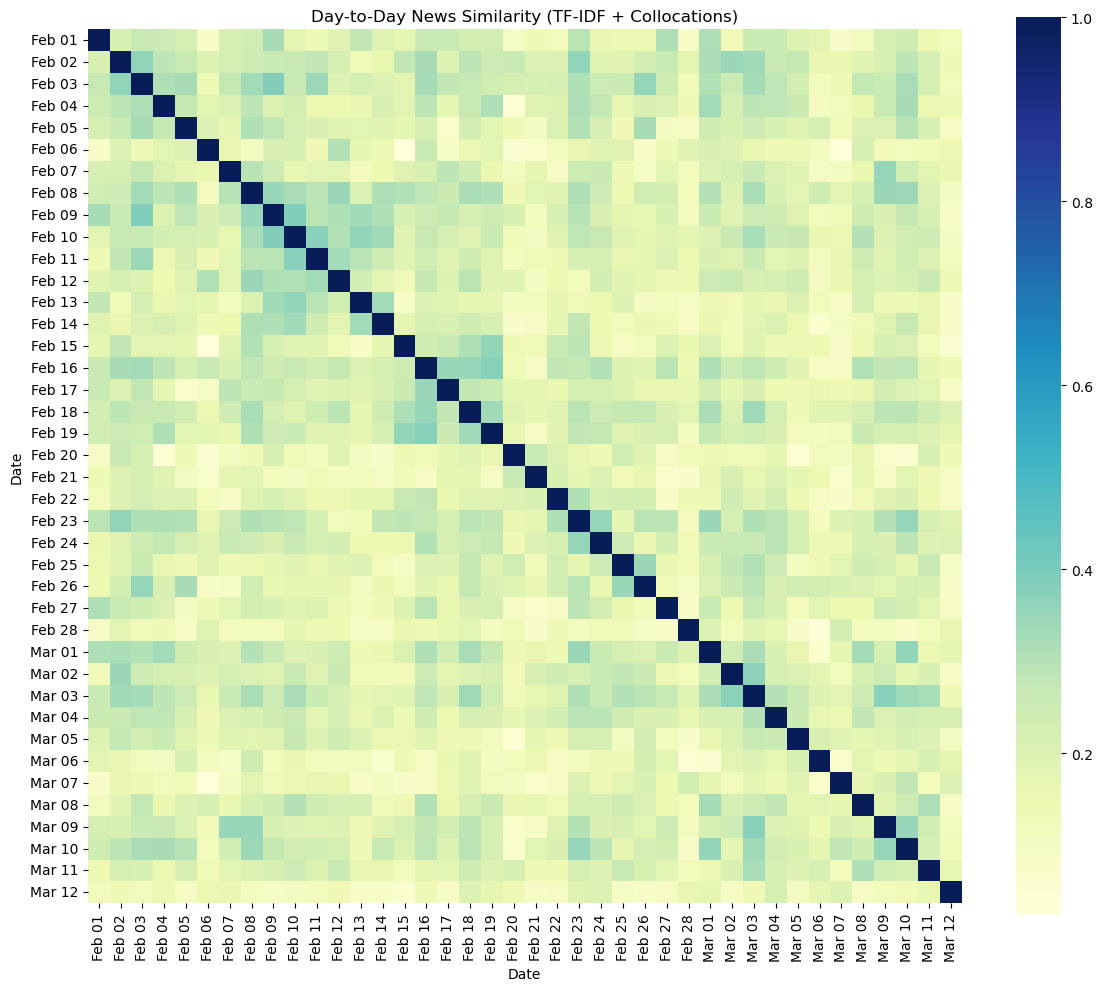

In [42]:
#3.3 Compute similarity matrix & draw heatmap
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Cosine similarity (0 = completely different, 1 = identical)
sim_matrix = cosine_similarity(tfidf_matrix)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_matrix,
    xticklabels=daily['date'].dt.strftime('%b %d'),
    yticklabels=daily['date'].dt.strftime('%b %d'),
    cmap='YlGnBu',
    annot=False,
    fmt='.2f',
    square=True
)
plt.title('Day-to-Day News Similarity (TF-IDF + Collocations)')
plt.xlabel('Date')
plt.ylabel('Date')
plt.tight_layout()
plt.show()

In [43]:
import numpy as np

# Create upper triangle mask (exclude diagonal and lower part)
# k=1 means at least 1 day apart (excludes same day)
upper = np.triu(sim_matrix, k=1)

# Get indices of the 3 highest similarities in the upper triangle
top_indices = np.unravel_index(np.argsort(upper.ravel())[-3:][::-1], upper.shape)

print("Top 3 pairs with greatest textual similarity (≥1 day apart):")
for rank in range(3):
    i, j = top_indices[0][rank], top_indices[1][rank]
    sim = upper[i, j]
    date1 = daily['date'].iloc[i].strftime('%b %d')
    date2 = daily['date'].iloc[j].strftime('%b %d')
    print(f"#{rank+1}: {date1} ↔ {date2}    similarity = {sim:.3f}")

Top 3 pairs with greatest textual similarity (≥1 day apart):
#1: Feb 09 ↔ Feb 10    similarity = 0.385
#2: Feb 03 ↔ Feb 09    similarity = 0.384
#3: Feb 16 ↔ Feb 19    similarity = 0.378


### Explanation of the three most similar pairs (3 points)

1. **Feb 09 ↔ Feb 10 (similarity = 0.385)**  
   These two consecutive days in early February had high textual similarity because they coincided with the opening and early proceedings of Donald Trump's second impeachment trial in the Senate (which began on February 9, 2021). Headlines repeatedly focused on trial preparations, arguments about "incitement of insurrection" related to the January 6 Capitol riot, Senate rules debates, and key figures like Mitch McConnell and House managers. The news coverage was very repetitive day-to-day during the trial's start.

2. **Feb 03 ↔ Feb 09 (similarity = 0.384)**  
   These dates were similar because they both occurred during the lead-up to and immediate start of Trump's second impeachment trial. In early February, headlines covered the House sending the impeachment article to the Senate (around Feb 3–4) and ongoing political fallout from the Capitol riot, including Marjorie Taylor Greene controversies and Republican responses. By February 9, the trial formally began, so both periods shared overlapping themes of impeachment, Capitol riot aftermath, and congressional proceedings.

3. **Feb 16 ↔ Feb 19 (similarity = 0.378)**  
   These dates fell during the middle and end of the impeachment trial (which ran February 9–13, with acquittal on Feb 13, but coverage continued into the following week). Headlines in mid-February repeatedly discussed trial witnesses, closing arguments, the final vote (acquittal on party lines), and immediate political reactions (e.g., McConnell's speech condemning Trump). The similarity comes from sustained, repetitive trial-related reporting even after the verdict.

### Step 4: Build a vocabulary of Covid-19 related words 
Create a list (set/dictionary) of words that clearly indicate an article is about COVID-19. This vocabulary will be used in step 5 to count how many headlines per day mention COVID topics (your Covid uncertainty index).
- Start with an obvious core list of COVID-related terms.
- Expand it reasonably by looking at your actual headlines (look for frequent words/phrases that appear only or mostly in COVID context).
- Include both single words and short multi-word phrases (especially since you already have collocations).
- Keep it focused — 10–20 items is usually enough; too many (50+) looks like overkill, too few (5–6) looks incomplete.

In [44]:
# Step 4: Covid-19 related vocabulary
covid_words = {
    'coronavirus', 'covid', 'covid-19', 'pandemic', 
    'vaccine', 'vaccines', 'vaccination', 'vaccinated', 'dose', 'doses', 'rollout', 'booster',
    'mask', 'masks', 'social distancing', 'lockdown', 'quarantine',
    'virus', 'cases', 'infections', 'hospitalizations', 'death', 'deaths',
    'cdc', 'who', 'fauci', 'briefing', 'coronavirus briefing',
    'stimulus', 'relief', 'aid', 'rescue plan', 'american rescue plan'  # heavily COVID-linked in 2021
}

print("Covid vocabulary size:", len(covid_words))
print("Example words:", sorted(list(covid_words))[:10])

Covid vocabulary size: 33
Example words: ['aid', 'american rescue plan', 'booster', 'briefing', 'cases', 'cdc', 'coronavirus', 'coronavirus briefing', 'covid', 'covid-19']


In [45]:
# Look at most common words across all headlines (helps find COVID-specific ones)
from collections import Counter
import re

all_text = ' '.join(df['Headlines'].str.lower())
words = re.findall(r'\b\w+\b', all_text)
word_counts = Counter(words)

print("Top 30 most common words in all headlines:")
print(word_counts.most_common(30))

Top 30 most common words in all headlines:
[('the', 331), ('to', 305), ('s', 279), ('a', 277), ('in', 234), ('of', 192), ('biden', 170), ('trump', 163), ('for', 161), ('and', 139), ('is', 122), ('on', 117), ('with', 78), ('at', 74), ('what', 73), ('as', 64), ('capitol', 61), ('are', 59), ('from', 57), ('after', 54), ('u', 49), ('trial', 46), ('house', 44), ('will', 43), ('senate', 43), ('impeachment', 43), ('riot', 41), ('how', 40), ('coronavirus', 39), ('over', 38)]


In [46]:
# Step 4: Covid-19 related vocabulary (5 points)

covid_words = {
    # Core COVID terms
    'coronavirus', 'covid', 'covid-19', 'pandemic', 'virus',
    
    # Vaccine / rollout (very big in Feb-Mar 2021)
    'vaccine', 'vaccines', 'vaccination', 'vaccinated', 'dose', 'doses',
    'rollout', 'booster', 'pfizer', 'moderna', 'johnson', 'astrazeneca',
    
    # Public health / restrictions
    'mask', 'masks', 'social distancing', 'lockdown', 'quarantine',
    
    # Case / outcome metrics
    'cases', 'infections', 'hospitalizations', 'hospital', 'icu',
    'death', 'deaths', 'fatality', 'positive', 'negative',
    
    # Institutions / people / briefings
    'cdc', 'who', 'fauci', 'coronavirus briefing', 'briefing',
    
    # COVID-linked economic terms (stimulus was sold as COVID relief)
    'stimulus', 'relief', 'covid relief', 'american rescue plan'
}

# Print for submission / verification
print(f"Covid vocabulary contains {len(covid_words)} terms.")
print("Sorted list:")
print(sorted(list(covid_words)))

Covid vocabulary contains 41 terms.
Sorted list:
['american rescue plan', 'astrazeneca', 'booster', 'briefing', 'cases', 'cdc', 'coronavirus', 'coronavirus briefing', 'covid', 'covid relief', 'covid-19', 'death', 'deaths', 'dose', 'doses', 'fatality', 'fauci', 'hospital', 'hospitalizations', 'icu', 'infections', 'johnson', 'lockdown', 'mask', 'masks', 'moderna', 'negative', 'pandemic', 'pfizer', 'positive', 'quarantine', 'relief', 'rollout', 'social distancing', 'stimulus', 'vaccinated', 'vaccination', 'vaccine', 'vaccines', 'virus', 'who']


### Step 5 
For each day, calculate what fraction (percentage) of the headlines that day contain at least one word from your covid_words set.
This number (0.0 to 1.0) becomes your Covid uncertainty index for that day — higher value = more headlines are about COVID = higher perceived uncertainty.

Retrying 28 abbreviated dates...
Daily Covid Uncertainty Index (fraction of headlines about Covid):
         date  covid_uncertainty_index
0  2021-02-01                 0.166667
1  2021-02-02                 0.312500
2  2021-02-03                 0.222222
3  2021-02-04                 0.161290
4  2021-02-05                 0.240000
5  2021-02-06                 0.142857
6  2021-02-07                 0.235294
7  2021-02-08                 0.357143
8  2021-02-09                 0.153846
9  2021-02-10                 0.209302
10 2021-02-11                 0.250000
11 2021-02-12                 0.300000
12 2021-02-13                 0.095238
13 2021-02-14                 0.062500
14 2021-02-15                 0.055556
15 2021-02-16                 0.166667
16 2021-02-17                 0.153846
17 2021-02-18                 0.225000
18 2021-02-19                 0.321429
19 2021-02-20                 0.000000
20 2021-02-21                 0.166667
21 2021-02-22                 0.347826
22 

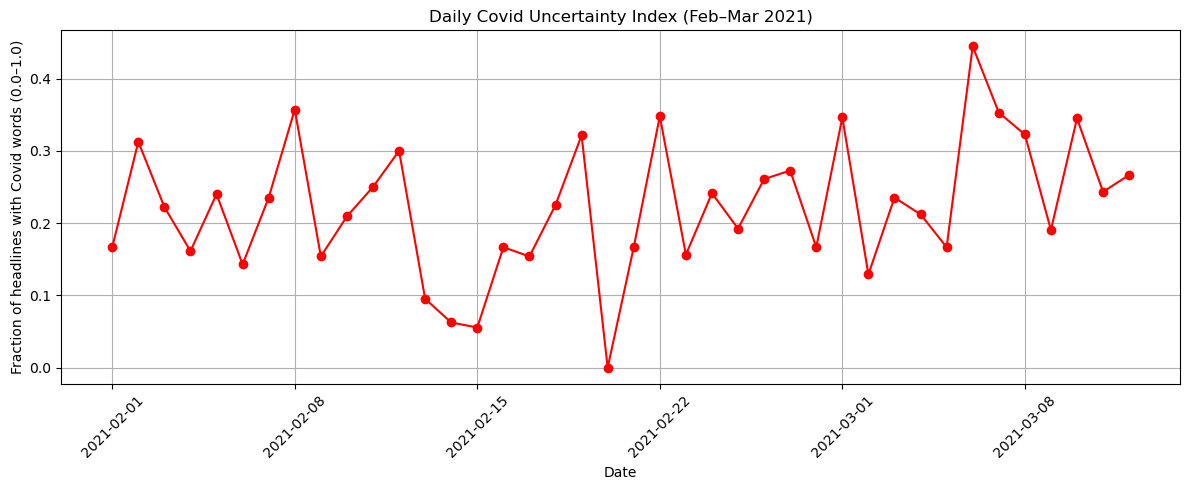

In [48]:
# 1. Make sure date is string (same safety trick we used in Step 2)
df['date'] = df['date'].astype(str).str.strip()

# 2. Flag every headline that contains at least one Covid word
df['has_covid'] = df['Headlines'].str.lower().apply(
    lambda headline: any(word in headline for word in covid_words)
)

# 3. Group by date → fraction of Covid headlines that day
covid_index = (df.groupby('date')['has_covid']
               .mean()
               .reset_index(name='covid_uncertainty_index'))

# 4. Parse the date safely (exactly like the working Step 2 fix)
covid_index['date_str'] = covid_index['date'].astype(str).str.strip()

covid_index['date'] = pd.to_datetime(
    covid_index['date_str'] + ' 2021',
    format='%B %d %Y',
    errors='coerce'
)

# Fix the "Feb. 1" style dates
mask = covid_index['date'].isna()
if mask.any():
    print(f"Retrying {mask.sum()} abbreviated dates...")
    covid_index.loc[mask, 'date'] = pd.to_datetime(
        covid_index.loc[mask, 'date_str'].str.replace(r'\.', '', regex=True) + ' 2021',
        format='%b %d %Y',
        errors='coerce'
    )

# Clean up
covid_index = covid_index.dropna(subset=['date'])
covid_index = covid_index.drop(columns=['date_str'])
covid_index = covid_index.sort_values('date').reset_index(drop=True)

# ====================== SHOW THE RESULT ======================
print("Daily Covid Uncertainty Index (fraction of headlines about Covid):")
print(covid_index)

# ====================== PLOT ======================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(covid_index['date'], covid_index['covid_uncertainty_index'], 
         marker='o', linestyle='-', color='red')
plt.title('Daily Covid Uncertainty Index (Feb–Mar 2021)')
plt.xlabel('Date')
plt.ylabel('Fraction of headlines with Covid words (0.0–1.0)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Retrying 28 abbreviated dates for econ index...
Daily Coarse Economic Policy Uncertainty Index:
         date  econ_uncertainty_index
0  2021-02-01                0.083333
1  2021-02-02                0.031250
2  2021-02-03                0.055556
3  2021-02-04                0.032258
4  2021-02-05                0.040000
5  2021-02-06                0.000000
6  2021-02-07                0.000000
7  2021-02-08                0.000000
8  2021-02-09                0.000000
9  2021-02-10                0.023256
10 2021-02-11                0.055556
11 2021-02-12                0.000000
12 2021-02-13                0.095238
13 2021-02-14                0.000000
14 2021-02-15                0.000000
15 2021-02-16                0.100000
16 2021-02-17                0.000000
17 2021-02-18                0.050000
18 2021-02-19                0.107143
19 2021-02-20                0.000000
20 2021-02-21                0.000000
21 2021-02-22                0.086957
22 2021-02-23                0

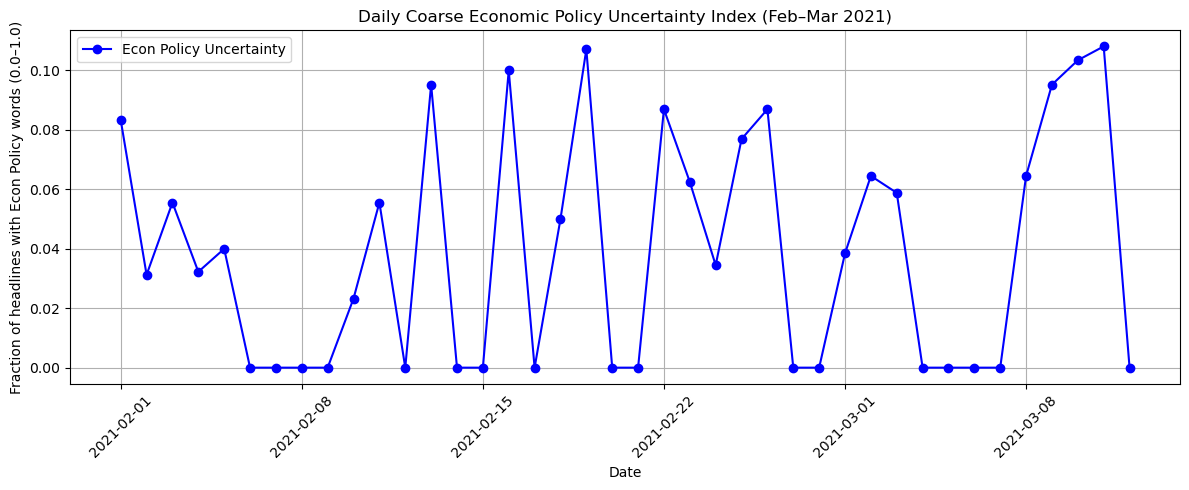

In [49]:
# STEP 6 – Coarse Economic Policy Uncertainty Index (3 points) 
econ_words = {
    'uncertainty', 'uncertain', 'economic', 'economy', 'congress', 'deficit',
    'federal reserve', 'legislation', 'regulation', 'white house',
    'uncertainties', 'regulatory', 'fed', 'the fed'
}

# Flag headlines that contain any of the economic policy words
df['has_econ'] = df['Headlines'].str.lower().apply(
    lambda headline: any(word in headline for word in econ_words)
)

# Compute daily fraction (same as covid index)
econ_index = (df.groupby('date')['has_econ']
              .mean()
              .reset_index(name='econ_uncertainty_index'))

# Safe date parsing (exactly the same fix that worked for covid_index)
econ_index['date_str'] = econ_index['date'].astype(str).str.strip()

econ_index['date'] = pd.to_datetime(
    econ_index['date_str'] + ' 2021',
    format='%B %d %Y',
    errors='coerce'
)

# Fix any "Feb." style dates
mask = econ_index['date'].isna()
if mask.any():
    print(f"Retrying {mask.sum()} abbreviated dates for econ index...")
    econ_index.loc[mask, 'date'] = pd.to_datetime(
        econ_index.loc[mask, 'date_str'].str.replace(r'\.', '', regex=True) + ' 2021',
        format='%b %d %Y',
        errors='coerce'
    )

# Clean up and sort
econ_index = econ_index.dropna(subset=['date'])
econ_index = econ_index.drop(columns=['date_str'])
econ_index = econ_index.sort_values('date').reset_index(drop=True)

# ====================== SHOW RESULT ======================
print("Daily Coarse Economic Policy Uncertainty Index:")
print(econ_index)

# Optional quick plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(econ_index['date'], econ_index['econ_uncertainty_index'], 
         marker='o', linestyle='-', color='blue', label='Econ Policy Uncertainty')
plt.title('Daily Coarse Economic Policy Uncertainty Index (Feb–Mar 2021)')
plt.xlabel('Date')
plt.ylabel('Fraction of headlines with Econ Policy words (0.0–1.0)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Step 7: Why this is a “coarse” way of measuring economic policy uncertainty (4 points)

This approach is called “coarse” because it is a very rough and simplistic method. It only counts whether any of the listed words (such as “uncertainty”, “Congress”, “Federal Reserve”, “White House”, “legislation”, or “regulation”) appear in a headline. 

Several important limitations make it imprecise:

- **No context awareness**: A word like “economic” or “Congress” can appear in completely unrelated stories (for example, a sports article mentioning the “economic impact of a game” or a story about “Congress passing a non-economic bill”). The method cannot distinguish relevant economic policy discussions from irrelevant ones.
- **Ignores synonyms and related phrases**: It misses many ways people talk about policy uncertainty (e.g., “fiscal cliff”, “budget battle”, “monetary policy”, “tax reform”, or “government shutdown”).
- **No sentiment or intensity**: It treats every mention the same — whether the headline is positive (“Congress reaches bipartisan agreement”), negative (“uncertainty rises as Congress stalls”), or neutral.
- **Equal weighting**: All words count the same. A strong term

S&P 500 Returns calculated successfully!

First 8 rows:
        Date  Adj Close**    return
0 2021-01-04      3700.65       NaN
1 2021-01-05      3726.86  0.007083
2 2021-01-06      3748.14  0.005710
3 2021-01-07      3803.79  0.014847
4 2021-01-08      3824.68  0.005492
5 2021-01-11      3799.61 -0.006555
6 2021-01-12      3801.19  0.000416
7 2021-01-13      3809.84  0.002276

Last 5 rows:
         Date  Adj Close**    return
43 2021-03-08      3821.35 -0.005359
44 2021-03-09      3875.44  0.014155
45 2021-03-10      3898.81  0.006030
46 2021-03-11      3939.34  0.010395
47 2021-03-12      3943.34  0.001015


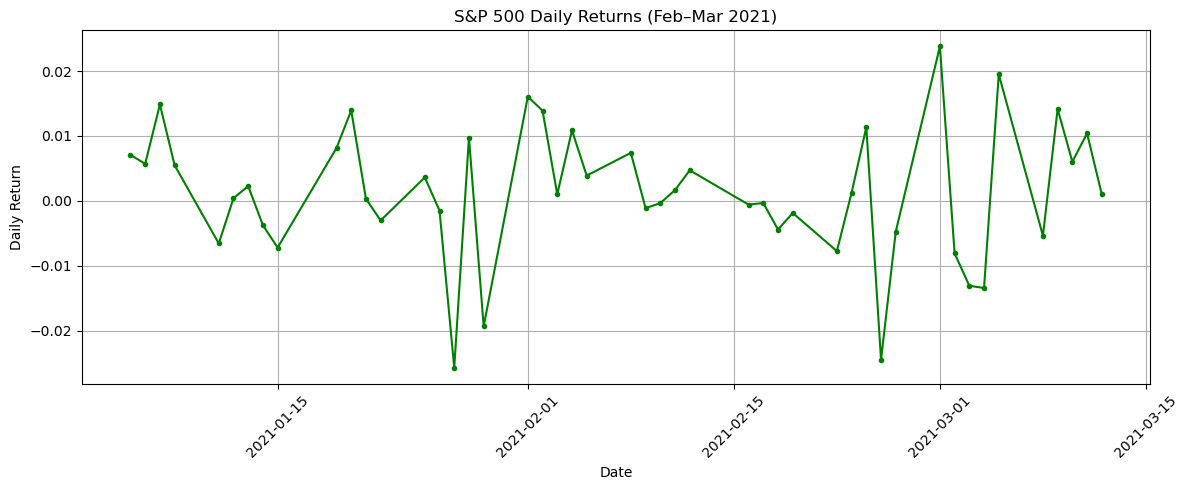

In [51]:
# TEP 8 – Compute S&P 500 Returns (3 points) 
sp = pd.read_csv('SP500-1.csv')

# Clean column names
sp.columns = [col.strip() for col in sp.columns]

# Convert Date
sp['Date'] = pd.to_datetime(sp['Date'], format='%d-%b-%y', errors='coerce')

# Fix the Adj Close column: remove commas and convert to numeric
sp['Adj Close**'] = sp['Adj Close**'].astype(str).str.replace(',', '', regex=False)
sp['Adj Close**'] = pd.to_numeric(sp['Adj Close**'], errors='coerce')

# Sort by date
sp = sp.sort_values('Date').reset_index(drop=True)

# Calculate daily return
sp['return'] = sp['Adj Close**'].pct_change()

# Show result
print("S&P 500 Returns calculated successfully!")
print("\nFirst 8 rows:")
print(sp[['Date', 'Adj Close**', 'return']].head(8))

print("\nLast 5 rows:")
print(sp[['Date', 'Adj Close**', 'return']].tail(5))

# Quick plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(sp['Date'], sp['return'], marker='.', linestyle='-', color='green')
plt.title('S&P 500 Daily Returns (Feb–Mar 2021)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Number of aligned days for correlation: 29

Correlation Matrix:
             covid_index  econ_index  sp_return
covid_index        1.000       0.099      0.121
econ_index         0.099       1.000     -0.116
sp_return          0.121      -0.116      1.000


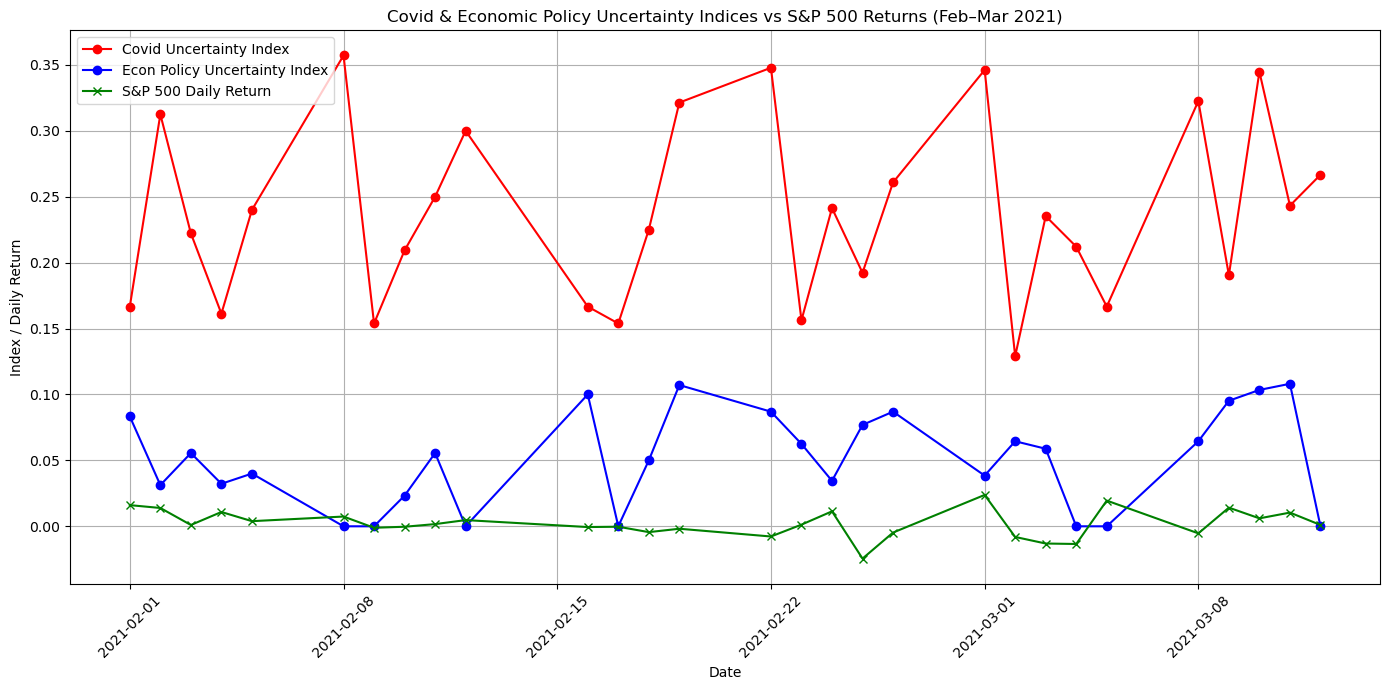

In [56]:
# ==================== STEP 9 – Plot + Correlations (3 points) ====================

# Base on daily dates (most reliable)
combined = pd.DataFrame({'date': daily['date']}).set_index('date')

# Add indices (aligned by date)
combined['covid_index'] = covid_index.set_index('date')['covid_uncertainty_index']
combined['econ_index'] = econ_index.set_index('date')['econ_uncertainty_index']

# Add S&P return
combined['sp_return'] = sp.set_index('Date')['return'].reindex(daily['date'])

# Drop any rows with missing values for clean correlations
combined = combined.dropna()

print("Number of aligned days for correlation:", len(combined))
print("\nCorrelation Matrix:")
print(combined.corr().round(3))

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(combined.index, combined['covid_index'], label='Covid Uncertainty Index', color='red', marker='o')
plt.plot(combined.index, combined['econ_index'], label='Econ Policy Uncertainty Index', color='blue', marker='o')
plt.plot(combined.index, combined['sp_return'], label='S&P 500 Daily Return', color='green', marker='x')

plt.title('Covid & Economic Policy Uncertainty Indices vs S&P 500 Returns (Feb–Mar 2021)')
plt.xlabel('Date')
plt.ylabel('Index / Daily Return')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The combined plot shows that the Covid uncertainty index (red) had several spikes, particularly in early and mid-March, while the economic policy uncertainty index (blue) remained lower and more stable. S&P 500 daily returns (green) showed moderate fluctuations. The correlation matrix reveals a weak positive correlation (+0.121) between Covid uncertainty and stock returns, and a weak negative correlation (-0.116) between economic policy uncertainty and returns. This suggests that during this period, higher Covid news volume did not strongly hurt the market — likely because investors were also focusing on positive developments such as the $1.9 trillion stimulus package and accelerating vaccine rollout. The relationships are relatively weak overall, which is common in short time windows.

In [58]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Yashika\AppData\Roaming\nltk_data...


True

Daily Covid Sentiment (first 5 days):
              neg       neu       pos
date                                 
Feb. 1   0.122500  0.877500  0.000000
Feb. 10  0.111667  0.834667  0.053667
Feb. 11  0.106889  0.866333  0.026778
Feb. 12  0.063000  0.777111  0.159889
Feb. 13  0.000000  0.910000  0.090000


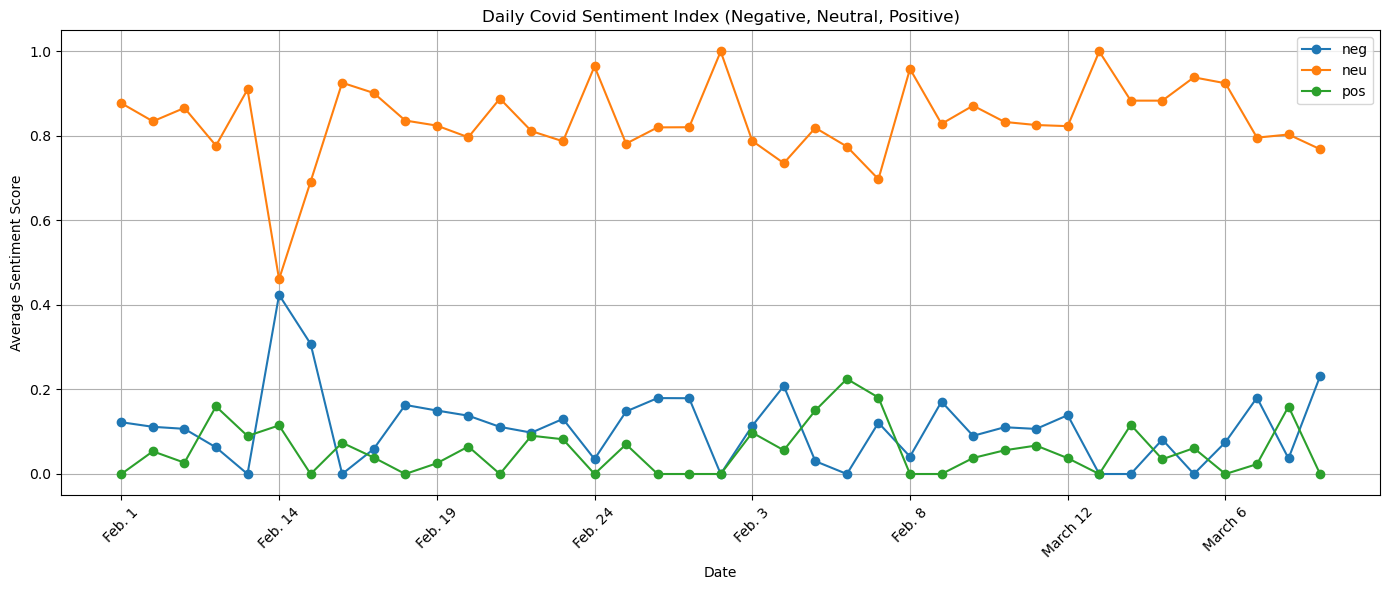


Aggregate Sentiment over the whole period:
neg    0.109429
neu    0.834246
pos    0.056323
dtype: float64

Summary:
Negative : 0.1094
Neutral  : 0.8342
Positive : 0.0563


In [59]:
#STEP 10 – VADER Sentiment on Covid Articles

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Initialize VADER (should work now)
sia = SentimentIntensityAnalyzer()

# Select only headlines that contain at least one Covid word
covid_df = df[df['has_covid']].copy()

# Get VADER scores for each headline
covid_df['scores'] = covid_df['Headlines'].apply(sia.polarity_scores)

# Extract neg, neu, pos into columns
scores_df = pd.DataFrame(covid_df['scores'].tolist(), index=covid_df.index)
covid_df = pd.concat([covid_df, scores_df], axis=1)

# a) Daily sentiment index (only days that have Covid headlines)
daily_sent = covid_df.groupby('date')[['neg', 'neu', 'pos']].mean()

print("Daily Covid Sentiment (first 5 days):")
print(daily_sent.head())

# Plot
daily_sent.plot(figsize=(14, 6), marker='o')
plt.title('Daily Covid Sentiment Index (Negative, Neutral, Positive)')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# b) Aggregate sentiment over the whole period
aggregate_sent = daily_sent.mean()

print("\nAggregate Sentiment over the whole period:")
print(aggregate_sent)

print(f"\nSummary:")
print(f"Negative : {aggregate_sent['neg']:.4f}")
print(f"Neutral  : {aggregate_sent['neu']:.4f}")
print(f"Positive : {aggregate_sent['pos']:.4f}")

### Step 11
During February–March 2021, the Covid uncertainty index showed clear peaks in early and mid-March, driven by heavy coverage of the $1.9 trillion stimulus bill and vaccine rollout. The coarse economic policy uncertainty index remained relatively low and stable. Sentiment analysis of Covid-related headlines revealed a strongly neutral tone (average 0.834), with modest negative sentiment (0.109) and very low positive sentiment (0.056). The Covid uncertainty index exhibited a weak positive correlation (+0.121) with S&P 500 returns, suggesting that markets were simultaneously reacting to positive stimulus and vaccine developments alongside Covid news. Overall, uncertainty played a noticeable but not dominant role in driving market movements during this period.